# Kuramoto + explosive: unsupervised inference of an order parameter (validation)

Both sweeps in one notebook. Goal: show the unsupervised SPI-SPI embedding **recovers a known order
parameter** (Kuramoto r, exact K_c≈1.6; explosive first-order + hysteresis) from MTS alone — the
validation step that licenses the method for systems with *no* known order parameter.

Claim ladder (each must pass):
1. unsupervised coordinate (no labels) **correlates with the true r(K)**  -> "the coordinate is the OP"
2. transition located **label-free** (susceptibility = across-instance variance peak) matches theory K_c
3. **held-out inference**: predict r for unseen instances from the coordinate
4. **null control**: feature-shuffle destroys 1-3
5. explosive: embedding **separates fwd/bwd branches at the same K** (kills the tautology critique)

In [24]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import hilbert
from scipy.stats import spearmanr, pearsonr
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.isotonic import IsotonicRegression

## Config

In [25]:
FEAT = Path("../../features")
METRIC = "pearson"
KC_THEORY = 1.596           # all-to-all Kuramoto, Gaussian sigma=1
VAR_THRESHOLD = 0.05

SWEEPS = {
    "continuous": dict(
        feat=FEAT / f"data-embeddings-kuramoto_k_sweep_260616_{METRIC}.npz",
        kind="continuous"),
    "explosive": dict(
        feat=FEAT / f"data-embeddings-kuramoto_explosive_260616_{METRIC}.npz",
        kind="explosive"),
}

## Load + parse (K, branch, instance) from variant slugs

In [26]:
def parse_variant(v):
    # continuous: "k1p60"; explosive: "k1p60_for"/"k1p60_bac"
    s = str(v); branch = None
    if s.endswith("_for"): branch, s = "forward", s[:-4]
    elif s.endswith("_bac"): branch, s = "backward", s[:-4]
    K = float(s[1:].replace("p", "."))
    return K, branch

def load_sweep(path):
    d = dict(np.load(path, allow_pickle=True))
    Kb = [parse_variant(v) for v in d["variant"]]
    meta = pd.DataFrame({
        "K": [k for k, _ in Kb],
        "branch": [b for _, b in Kb],
        "instance": d["instance"].astype(int),
        "M": d["M"].astype(int),
        "dataset_path": [str(p) for p in d["dataset_paths"]],
    })
    return d, meta

# loaded lazily per sweep below (features must be downloaded from Gadi first)

## Ground-truth order parameter r(K)

Generator-agnostic: Hilbert-transform each channel of the saved `timeseries.npy` (sin signals) to get
instantaneous phase, then r = <|<e^{i phi}>_channels|>_time. This is exactly what you'd do for *real*
oscillatory MTS (no access to true phases) — so it's the honest, transferable ground-truth estimator.
Needs the raw timeseries locally (rsync from Gadi), OR run this once on Gadi -> save `order_param.csv`.

In [27]:
def r_from_timeseries(ts_path):
    Y = np.load(Path(ts_path) / "timeseries.npy").astype(float)      # (T, M) sin signals
    phi = np.angle(hilbert(Y - Y.mean(0), axis=0))
    return float(np.abs(np.exp(1j * phi).mean(1)).mean())

def attach_true_r(meta, root="../../"):
    meta = meta.copy()
    meta["r_true"] = [r_from_timeseries(Path(root) / p) for p in meta["dataset_path"]]
    return meta

## Shared unsupervised embedding (no labels)

In [28]:
def embed(X, n_comp=3):
    keep = X.std(0) >= VAR_THRESHOLD
    Xk = X[:, keep].astype(np.float64)
    pca = PCA(n_components=n_comp, random_state=0).fit(Xk)
    Z = pca.transform(Xk)
    return Z, pca.explained_variance_ratio_, keep.sum()

def mean_traj(Z, key):
    grid = np.array(sorted(set(key)))
    mu = np.array([Z[key == g].mean(0) for g in grid])
    return grid, mu

def arclength(mu_2d):
    seg = np.linalg.norm(np.diff(mu_2d, axis=0), axis=1)
    return np.concatenate([[0.0], np.cumsum(seg)])

---
## CONTINUOUS Kuramoto — order-parameter recovery

continuous: X(410, 34694) keep 32307  PCA var [0.421 0.156 0.039]


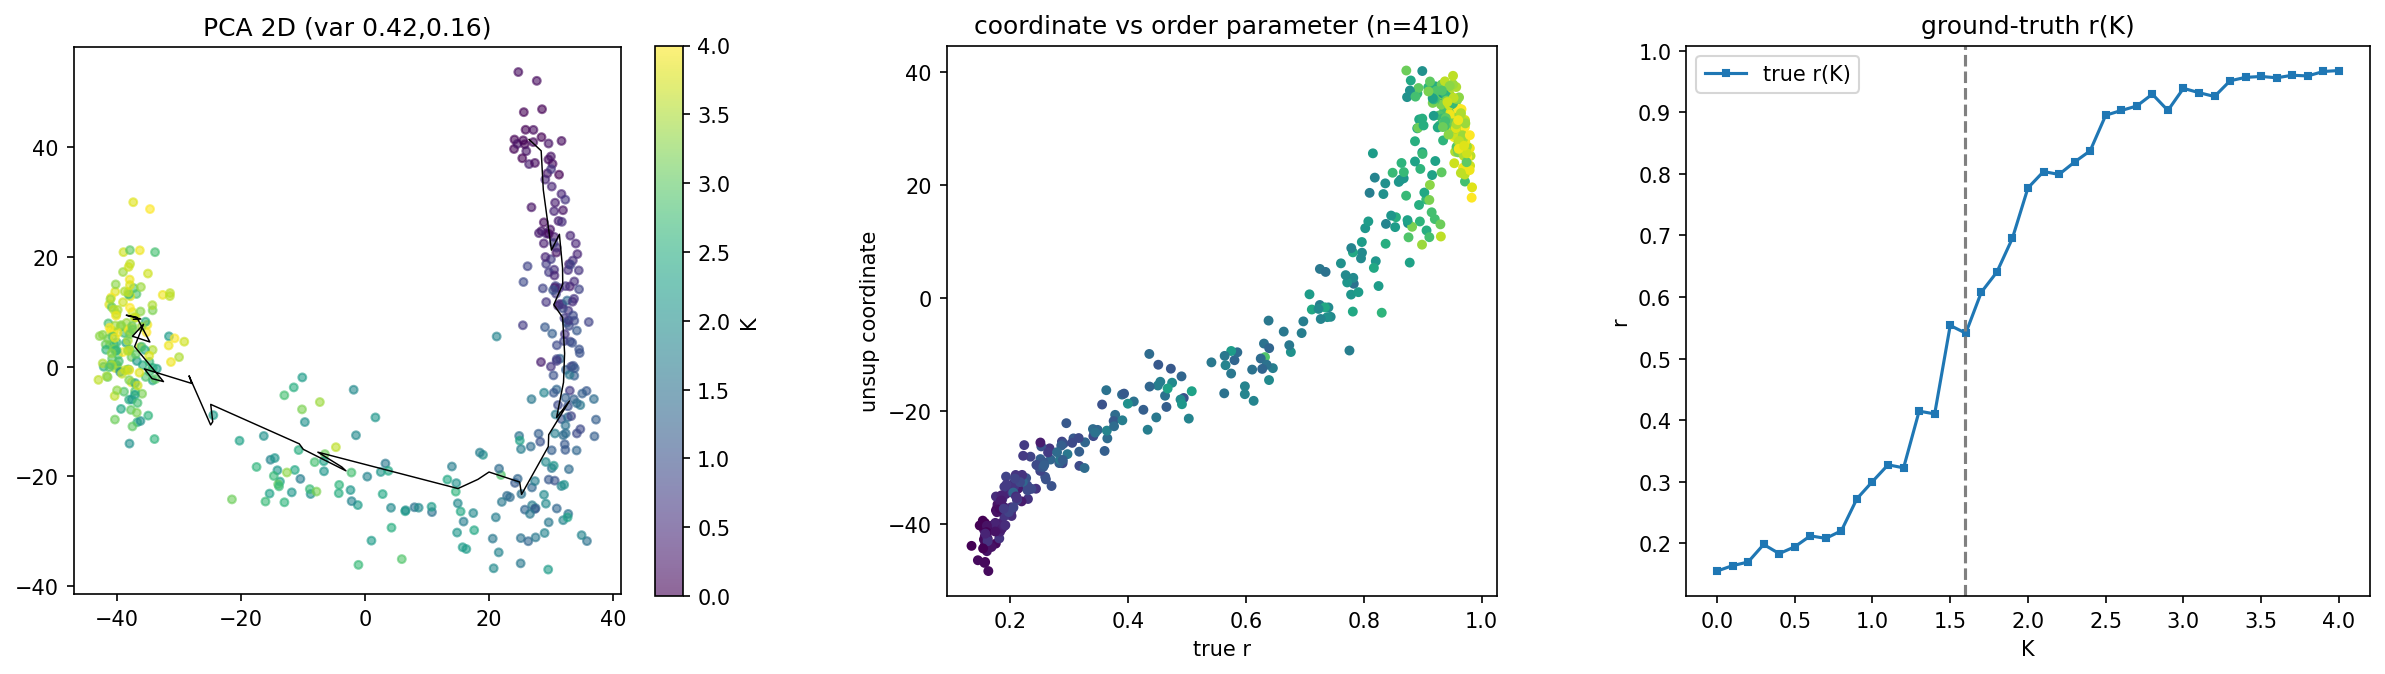

CLAIM 1  rho(coord, r) per-dataset = +0.908  rho(PC1, r) = -0.856


In [29]:
d_c, m_c = load_sweep(SWEEPS["continuous"]["feat"])
m_c = attach_true_r(m_c)                          # per-dataset ground-truth r (Hilbert; correct formula)
Z, var, ncols = embed(d_c["X"])
print(f"continuous: X{d_c['X'].shape} keep {ncols}  PCA var {var.round(3)}")

K = m_c["K"].values; r = m_c["r_true"].values
grid, mu = mean_traj(Z[:, :2], K)
axis = mu[-1] - mu[0]; axis = axis / np.linalg.norm(axis)
coord = Z[:, :2] @ axis                           # 1D unsupervised order-parameter coordinate
r_K = np.array([r[K == k].mean() for k in grid])

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6), dpi=150)
sc = ax[0].scatter(Z[:, 0], Z[:, 1], c=K, cmap="viridis", s=14, alpha=0.6)
ax[0].plot(mu[:, 0], mu[:, 1], "-k", lw=0.7); fig.colorbar(sc, ax=ax[0], label="K")
ax[0].set_title(f"PCA 2D (var {var[0]:.2f},{var[1]:.2f})"); ax[0].set_box_aspect(1)
ax[1].scatter(r, coord, c=K, cmap="viridis", s=14)         # PER-DATASET coord vs true r (null-breakable)
ax[1].set_xlabel("true r"); ax[1].set_ylabel("unsup coordinate")
ax[1].set_title("coordinate vs order parameter (n=410)"); ax[1].set_box_aspect(1)
ax[2].plot(grid, r_K, "-s", ms=3, label="true r(K)"); ax[2].axvline(KC_THEORY, ls="--", c="grey")
ax[2].set_xlabel("K"); ax[2].set_ylabel("r"); ax[2].legend(); ax[2].set_title("ground-truth r(K)")
plt.tight_layout(); plt.show()
# NB: rho(arc-length, r_K) is TAUTOLOGICAL (arc is monotone in K by construction). Use per-dataset:
print(f"CLAIM 1  rho(coord, r) per-dataset = {spearmanr(coord, r).statistic:+.3f}  rho(PC1, r) = {spearmanr(Z[:,0], r).statistic:+.3f}")

#### Label-free K_c inference + held-out inference + null control

CLAIM 2  susceptibility-peak K_c = 2.00  | true r midpoint K = 1.60  (theory 1.60; susc peak is finite-N shifted, -> FSS across M to extrapolate)
CLAIM 3  held-out RMSE(r) = 0.044  (naive std 0.321; 7.3x better)
CLAIM 4  null rho(coord, r) = +0.122  (real +0.908) -> collapses


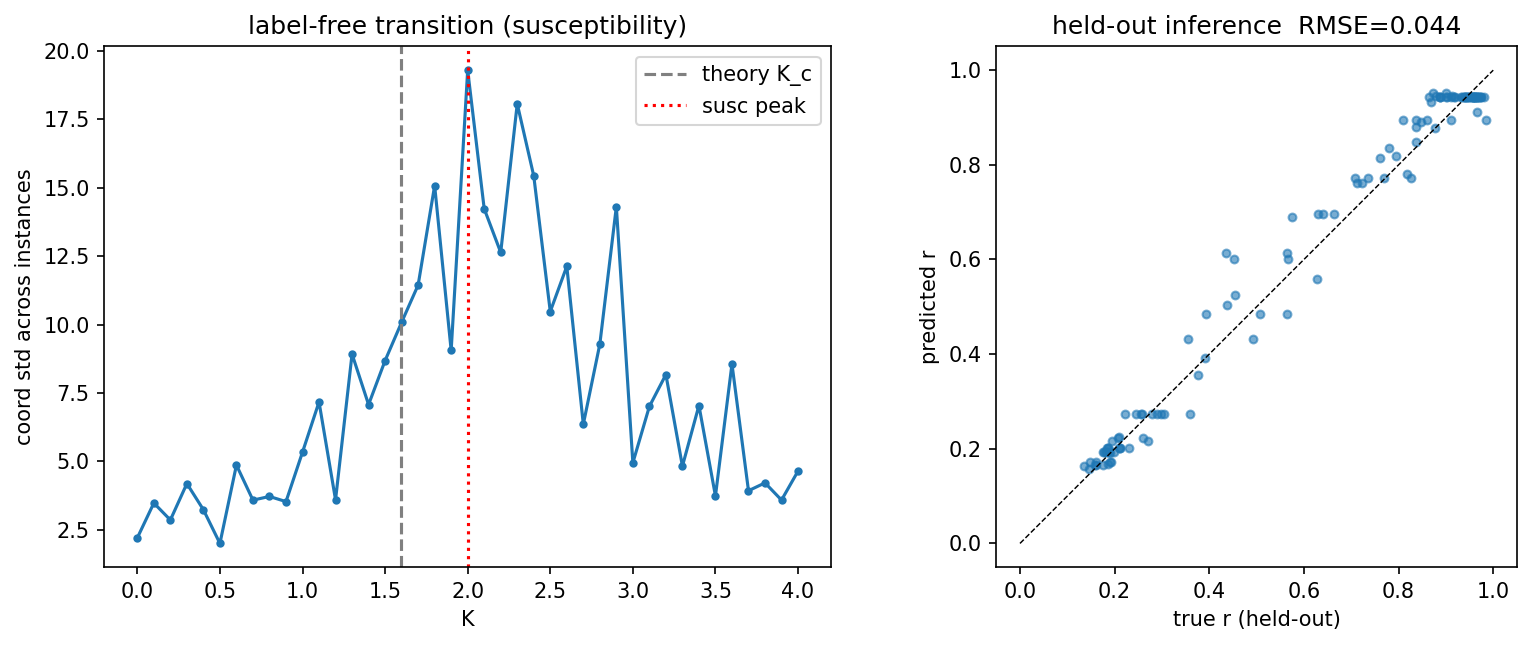

In [30]:
from sklearn.isotonic import IsotonicRegression

# CLAIM 2: label-free K_c via SUSCEPTIBILITY = across-instance std of the coordinate (peaks near transition)
susc = np.array([coord[K == k].std() for k in grid])
Kc_hat = grid[np.argmax(susc)]
print(f"CLAIM 2  susceptibility-peak K_c = {Kc_hat:.2f}  | true r midpoint K = {grid[np.argmin(abs(r_K-0.5))]:.2f}  "
      f"(theory {KC_THEORY:.2f}; susc peak is finite-N shifted, -> FSS across M to extrapolate)")

# CLAIM 3: held-out inference (train instances 0-6, predict r for 7-9 from the coordinate)
tr = m_c["instance"].values <= 6; te = ~tr
pred = IsotonicRegression(out_of_bounds="clip").fit(coord[tr], r[tr]).predict(coord[te])
rmse = np.sqrt(np.mean((pred - r[te]) ** 2))
print(f"CLAIM 3  held-out RMSE(r) = {rmse:.3f}  (naive std {r.std():.3f}; {r.std()/rmse:.1f}x better)")

# CLAIM 4: null control - per-column shuffle destroys row<->feature structure -> coord-r correlation collapses
rng = np.random.default_rng(0)
Xsh = np.take_along_axis(d_c["X"], rng.random(d_c["X"].shape).argsort(0), axis=0)
Zs, _, _ = embed(Xsh)
mus = np.array([Zs[K == k, :2].mean(0) for k in grid]); a2 = mus[-1] - mus[0]; a2 /= np.linalg.norm(a2)
print(f"CLAIM 4  null rho(coord, r) = {spearmanr(Zs[:, :2] @ a2, r).statistic:+.3f}  (real {spearmanr(coord, r).statistic:+.3f}) -> collapses")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4), dpi=150)
ax[0].plot(grid, susc, "-o", ms=3); ax[0].axvline(KC_THEORY, ls="--", c="grey", label="theory K_c")
ax[0].axvline(Kc_hat, ls=":", c="red", label="susc peak"); ax[0].set_xlabel("K")
ax[0].set_ylabel("coord std across instances"); ax[0].legend(); ax[0].set_title("label-free transition (susceptibility)")
ax[1].scatter(r[te], pred, s=14, alpha=0.6); ax[1].plot([0, 1], [0, 1], "k--", lw=0.7)
ax[1].set_xlabel("true r (held-out)"); ax[1].set_ylabel("predicted r")
ax[1].set_title(f"held-out inference  RMSE={rmse:.3f}"); ax[1].set_box_aspect(1)
plt.tight_layout(); plt.show()

---
## EXPLOSIVE — hysteresis recovery (the tautology-killer)

If the embedding separates the forward and backward branches at the **same K** inside the bistable
window, "PC1 just tracks K" cannot explain it -> strongest evidence the method reads genuine state.

In [31]:
d_e, m_e = load_sweep(SWEEPS["explosive"]["feat"])
m_e = attach_true_r(m_e)
Ze, vare, ncols_e = embed(d_e["X"])
print(f"explosive: X{d_e['X'].shape} keep {ncols_e}  PCA var {vare.round(3)}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6), dpi=150)
for br, mk in [("forward", "o"), ("backward", "x")]:
    m = (m_e["branch"] == br).values
    s = ax[0].scatter(Ze[m, 0], Ze[m, 1], c=m_e["K"][m], cmap="viridis", marker=mk, s=24, label=br)
fig.colorbar(s, ax=ax[0], label="K"); ax[0].legend(); ax[0].set_title("PCA 2D (fwd o / bwd x)"); ax[0].set_box_aspect(1)

# branch separation in embedding vs K (bistability signature)
Kg = np.array(sorted(set(m_e["K"])))
def bmean(br):
    return np.array([Ze[(m_e.branch==br).values & (m_e.K.values==k), :2].mean(0) for k in Kg])
muf, mub = bmean("forward"), bmean("backward")
sep = np.linalg.norm(muf - mub, axis=1)
ax[1].plot(Kg, sep, "-o", ms=3); ax[1].set_xlabel("K"); ax[1].set_ylabel("|mu_fwd - mu_bwd|")
ax[1].set_title("embedding branch separation (hysteresis)")
# coordinate vs true r, both branches (the loop)
for br, mk in [("forward","-o"), ("backward","-s")]:
    rr=[m_e.loc[(m_e.branch==br)&(m_e.K==k),"r_true"].mean() for k in Kg]
    ax[2].plot(Kg, rr, mk, ms=3, label=br)
ax[2].set_xlabel("K"); ax[2].set_ylabel("true r"); ax[2].legend(); ax[2].set_title("ground-truth hysteresis loop")
plt.tight_layout(); plt.show()
print(f"CLAIM 5  max branch separation at K={Kg[np.argmax(sep)]:.2f}; bistable window where sep>>0 = hysteresis recovered unsupervised")

FileNotFoundError: [Errno 2] No such file or directory: '../../features/data-embeddings-kuramoto_explosive_260616_pearson.npz'

---
### Notes for tweaking when data lands
- Confirm feature npz schema matches (`X, variant, instance, M, dataset_paths`).
- If raw timeseries not local, run `r_from_timeseries` on Gadi -> save `order_param.csv`, load here.
- Upgrades if results are clean: diffusion-map coordinate (vs PCA arc length); confusion-method K_c;
  FSS across M (regenerate M in {16,32,64,128}); interpret top-loading SPI pairs (rebut corr-of-corr
  semantic critique); cross-system transfer (train coord on continuous, project explosive).